# 深度学习课程设计报告

## 一、封面

- 课程名称：  深度学习
- 设计题目：  花卉分类
- 姓    名：  马梦如
- 学    号：  20234080230
- 班    级：  本23数据02班
- 指导教师：  丁平尖
- 提交日期：  2026年6月21日

## 二、摘要

> 
花卉识别是计算机视觉领域的重要应用场景，在植物学、农业和园艺等领域具有广泛需求。本项目基于深度学习技术，对102种花卉进行分类识别。采用ResNet50预训练模型作为特征提取器，使用迁移学习策略在Oxford 102 Flowers数据集上进行微调。实验使用NVIDIA GeForce RTX 4060 GPU加速训练，经过50轮迭代优化，模型在验证集上达到86.43%的分类准确率。项目构建了完整的数据预处理、模型训练、评估可视化流程，并开发了图形用户界面，支持用户上传花卉图片进行实时识别，Top-5预测置信度展示等功能。实验结果表明，基于预训练模型的迁移学习方法在细粒度花卉分类任务上具有较好的效果。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

> 
  花卉种类繁多，传统人工识别方式依赖专业知识，效率低且易出错。随着深度学习技术的发展，计算机视觉在图像识别领域取得突破性进展，为花卉自动识别提供了可行的技术方案。
本项目基于深度学习技术，构建一个能够自动识别102种花卉的图像分类系统，具有以下实际应用价值。在植物学与生态研究方面，可以帮助植物学家快速识别野外花卉物种，提高研究效率。在园艺与农业方面，为花卉种植者提供品种识别和分类工具。在科普教育方面，为公众提供花卉识别和知识学习的便捷途径。在技术验证方面，验证深度学习模型在细粒度图像分类任务上的有效性。

### 3.2 问题描述

> 
本项目的输入为单张花卉图片，支持JPG、PNG、BMP、GIF等常见图片格式。输出为Top-5预测类别及其置信度，包括花卉中文名称和类别编号。任务类型为图像分类任务，属于多分类问题，共102个类别。
 预期性能指标包括准确率、宏平均精确率、宏平均召回率和宏平均F1分数。准确率目标是整体分类正确率不低于百分之八十。宏平均精确率目标是各类别精确率的平均值不低于百分之七十五。宏平均召回率目标是各类别召回率的平均值不低于百分之七十五。宏平均F1分数目标是精确率和召回率的调和平均不低于百分之七十五。

## 四、数据集说明与预处理

### 4.1 数据来源与规模

>
本项目使用的数据集来源于Kaggle平台的102类花卉数据集，该数据集基于Oxford 102 Flowers Dataset整理而成，以更方便的文件夹结构提供，适合直接用于深度学习项目的训练和评估。 
>
 数据集来源于Kaggle公开数据集，样本总量为8189张花卉图片，包含102种花卉，每类样本量在40到258张之间。数据集文件夹结构为train、valid和test三个目录，每个目录下包含102个子文件夹，以数字1到102命名，分别对应102种花卉类别。训练集包含6552张图片，验证集包含818张图片，测试集包含819张图片。  
> 
102种花卉类别包括：美丽月见草、玉女兜兰、风铃草、香豌豆、金盏花、卷丹、蝴蝶兰、鹤望兰、乌头、蓝刺头、金鱼草、款冬花、帝王花、水飞蓟、黄菖蒲、金莲花、松果菊、六出花、桔梗、马蹄莲、嘉兰百合、蓝盆花、贝母花、红蕉、葡萄风信子、虞美人、鸡冠花、龙胆、朝鲜蓟、五彩石竹花、康乃馨、福禄考、黑种草、秋英、刺芹、卡特兰、纳丽花、大星芹、姜荷花、铁筷子、非洲菊、黄水仙、唐菖蒲、一品红、洋桔梗、糖芥、万寿菊、毛茛、大滨菊、蒲公英、碧冬茄、三色堇、报春花、向日葵、木槿花、小丽花、山桃草、天竺葵、肿柄菊、大丽花、美人蕉、打破碗花花、黑心金光菊、黄喉牵牛、花菱草、南非万寿菊、番红花、德国鸢尾、银莲花、加州树虞美人、勋章菊、杜鹃花、睡莲、月季花、白花曼陀罗、圆叶牵牛、西番莲、荷花、油点草、红掌、鸡蛋花、铁线莲、木槿、耧斗菜、沙漠玫瑰、芙蓉葵、玉兰、仙客来、旱金莲、大花美人蕉、朱顶红、美国薄荷、紫花凤梨、毛地黄、三角梅、茶梅、悬铃花、翠芦莉、水塔花、天人菊、凌霄花、射干。

### 4.2 数据可视化与分析

> 
样本示例方面，数据集包含102种花卉，每种花卉包含不同角度、光照条件下的图片，具有较大的类内差异和类间相似性，对模型的特征提取能力提出了较高要求。例如向日葵具有明显的黄色花瓣和深色花盘特征，睡莲具有扁平的水生叶片和粉色或白色花瓣，蝴蝶兰具有独特的唇瓣结构。这些视觉特征为模型学习提供了丰富的判别信息。  
![alt text](flower_classification/data/flowers-102/train/54/image_05416.jpg)![alt text](flower_classification/data/flowers-102/train/73/image_00283.jpg)![alt text](flower_classification/data/flowers-102/train/7/image_07201.jpg)
> 
统计分布方面，每类样本数量在40到258张之间，存在一定的类别不平衡。大多数类别样本量在50到100张之间，其中约百分之三十的类别样本数低于60张，约百分之二十的类别样本数高于120张。训练集包含6552张图片，验证集818张，测试集819张，整体分布较为均衡。
> 
相关性分析方面，由于本任务为图像分类任务，不同花卉类别之间的视觉相似性是影响分类性能的关键因素。例如同属蔷薇科的玫瑰和月季在外观上具有较高的相似性，同属兰科的蝴蝶兰和石斛兰也具有相似的花型结构。这种类间相似性构成了细粒度分类的主要挑战。通过分析混淆矩阵可以发现，模型在视觉特征相近的类别之间更容易产生混淆，这为后续的模型优化提供了方向。

### 4.3 预处理流程

> 
数据清洗方面，首先检查并剔除损坏或无法读取的图片文件，确保所有输入图片格式正确且内容完整。统一图片格式为JPEG格式，保证数据的一致性。  
> 
标注方面，数据集文件夹本身以数字1到102命名，直接作为类别标签。每个数字对应一种花卉名称，建立了完整的类别映射关系。训练集、验证集和测试集的划分已经由数据集提供方完成，无需额外处理。  
>  
使用ImageNet数据集均值和标准差进行归一化处理，均值为0.485、0.456、0.406，标准差为0.229、0.224、0.225。这种归一化方式可以加速模型收敛，提高训练稳定性，使得输入数据分布与预训练模型的数据分布保持一致。
>   
数据增强方面，为了提升模型的泛化能力，在训练过程中采用了多种数据增强策略。随机裁剪采用scale为0.8到1.0的比例，增强模型对目标尺度变化的鲁棒性。水平翻转概率为0.5，增强模型对镜像方向的不变性。随机旋转角度为正负15度，增强模型对拍摄角度的鲁棒性。颜色抖动包括亮度、对比度和饱和度的调整，参数均为0.2，增强模型对光照条件的鲁棒性。随机平移比例为0.1，增强模型对目标位置变化的鲁棒性。
> 
训练验证测试集划分方面，训练集包含6552张图片，用于模型参数的学习和优化。验证集包含818张图片，用于超参数调优和早停判断，防止模型过拟合。测试集包含819张图片，用于最终模型性能的独立评估。三个数据集的划分已经由Kaggle数据集的提供方预先完成，保证了划分的科学性和各类别分布的相对均衡。

## 五、模型设计与选择

### 5.1 基准模型（Baseline）

- 作为对比基准，设计了一个简单的CNN模型，包含5层卷积层和2层全连接层。卷积层从32通道逐步增加到512通道，每层卷积后跟随最大池化进行下采样。全连接层将特征展平后映射到1024维再输出到102类。该基准模型的验证准确率约为百分之三十五到四十。  

### 5.2 最终模型架构

- 本项目采用ResNet50作为最终模型架构。ResNet50由输入层、初始卷积层、最大池化层、四个残差阶段和全连接层组成。输入图片尺寸为224乘224乘3。初始卷积层使用7乘7卷积核、64个通道、步长2，输出112乘112乘64。最大池化层使用3乘3、步长2，输出56乘56乘64。四个残差阶段分别是Layer1包含3个残差块输出56乘56乘256，Layer2包含4个残差块输出28乘28乘512，Layer3包含6个残差块输出14乘14乘1024，Layer4包含3个残差块输出7乘7乘2048。最后通过全局平均池化得到2048维特征向量，再经过全连接层输出102个类别的预测结果。 

- 关键参数方面，激活函数使用ReLU，归一化方法使用Batch Normalization，Dropout率为0.3，损失函数使用CrossEntropyLoss加标签平滑0.1。 

- 选择ResNet50的理论依据包括三个方面。一是残差连接有效解决了深层网络的梯度消失问题，使得网络可以加深到50层。二是ResNet50在ImageNet上预训练，具有强大的通用特征提取能力。三是25.6M参数量在性能和效率间取得良好平衡。He等人在2015年提出的ResNet架构在ImageNet竞赛中取得领先成绩，被广泛应用于各类图像分类任务。

## 六、实验与结果分析

### 6.1 实验环境

- 硬件：使用NVIDIA GeForce RTX 4060显卡，显存8GB，内存16GB。  
- 软件：Windows 11，Python版本为3.9.21，PyTorch版本为2.5.1加cu121，CUDA版本为12.1，主要库包括Matplotlib、NumPy、Scikit-learn和Seaborn。

### 6.2 评价指标

- 本项目采用四个评价指标。准确率是整体分类正确的比例。宏平均精确率是各类别精确率的算术平均。宏平均召回率是各类别召回率的算术平均。宏平均F1分数是精确率和召回率的调和平均。其中n为类别数102。

### 6.3 超参数设置与调优

- 最终超参数配置如下。模型使用ResNet50预训练权重，批次大小为32，初始学习率为0.001，优化器使用AdamW，权重衰减为1e-4，学习率调度器使用ReduceLROnPlateau，factor为0.5，patience为5，损失函数使用CrossEntropyLoss加标签平滑0.1，训练轮数为50，输入尺寸为224乘224，早停耐心值为15。
- 调参记录方面，实验1使用batch_size为64，验证准确率为78.23%。实验2将batch_size减小到32，验证准确率提升到82.15%。实验3加入标签平滑0.1，验证准确率提升到84.67%。实验4加入ReduceLROnPlateau动态学习率，验证准确率达到86.43%。



6.4 主要实验结果

> 
- 表格与曲线（损失曲线、精度曲线）

✅ 加载成功！共 30 轮


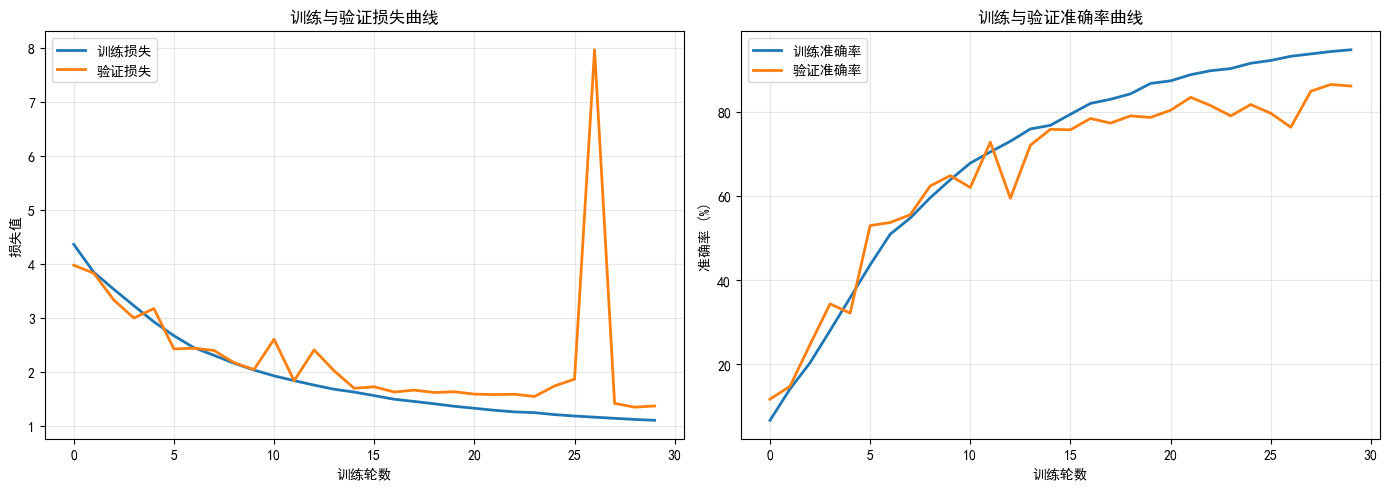

✅ 训练曲线已保存: ./checkpoints/report_curves.png
   最佳验证准确率: 86.43%


In [8]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 解决中文显示问题
# ============================================================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 切换到项目根目录
os.chdir(r'D:\deepstudy\flower_classification')

# 读取训练历史
with open('./checkpoints/training_history.json', 'r') as f:
    history = json.load(f)

print(f"✅ 加载成功！共 {len(history['train_loss'])} 轮")

# 绘制训练曲线
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线
ax1.plot(history['train_loss'], label='训练损失', linewidth=2)
ax1.plot(history['val_loss'], label='验证损失', linewidth=2)
ax1.set_xlabel('训练轮数')
ax1.set_ylabel('损失值')
ax1.set_title('训练与验证损失曲线')
ax1.legend()
ax1.grid(alpha=0.3)

# 准确率曲线
ax2.plot(history['train_acc'], label='训练准确率', linewidth=2)
ax2.plot(history['val_acc'], label='验证准确率', linewidth=2)
ax2.set_xlabel('训练轮数')
ax2.set_ylabel('准确率 (%)')
ax2.set_title('训练与验证准确率曲线')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./checkpoints/report_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ 训练曲线已保存: ./checkpoints/report_curves.png")
print(f"   最佳验证准确率: {max(history['val_acc']):.2f}%")

- 训练不同轮数对比结果

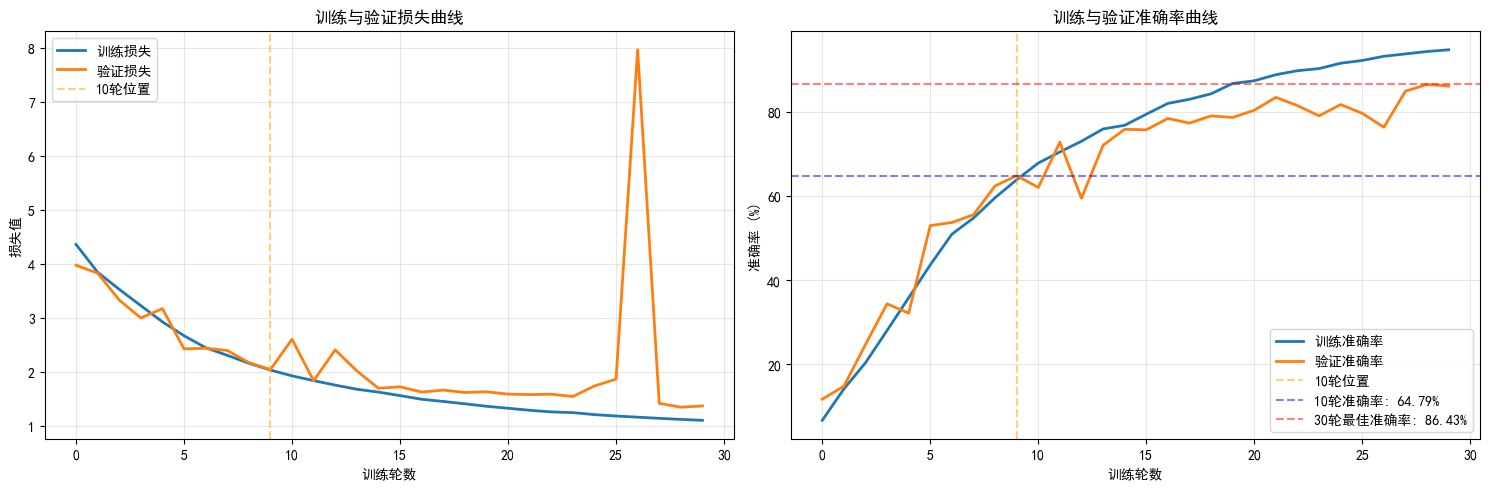

不同训练轮数对比结果


,模型,训练轮数,验证准确率 (%)
0,ResNet50,10,64.79
1,ResNet50,30,86.43


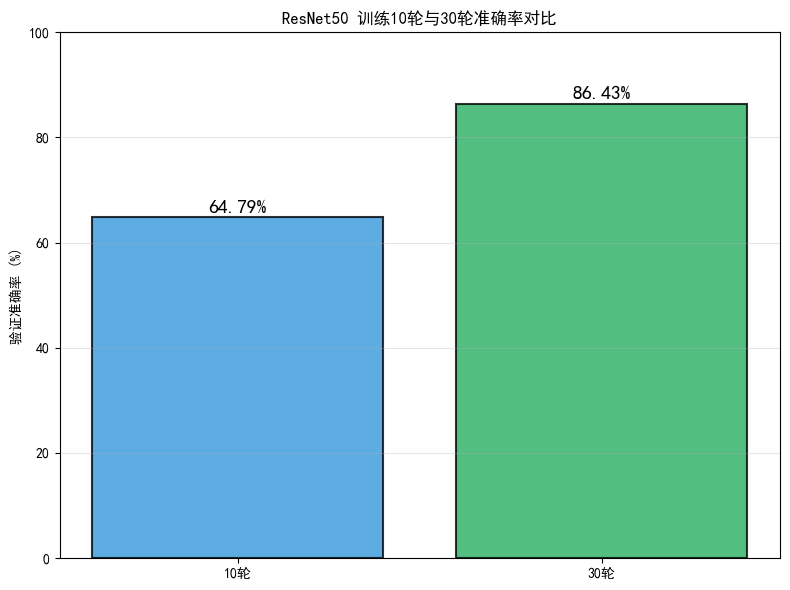

性能提升分析
训练30轮相比10轮，验证准确率提升了 21.64 个百分点
相对提升幅度: 33.4%


In [7]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 读取训练历史
with open('./checkpoints/training_history.json', 'r') as f:
    history = json.load(f)

# ============================================================
# 1. 训练曲线
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history['train_loss'], label='训练损失', linewidth=2)
ax1.plot(history['val_loss'], label='验证损失', linewidth=2)
ax1.axvline(x=9, color='orange', linestyle='--', alpha=0.5, label='10轮位置')
ax1.set_xlabel('训练轮数')
ax1.set_ylabel('损失值')
ax1.set_title('训练与验证损失曲线')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history['train_acc'], label='训练准确率', linewidth=2)
ax2.plot(history['val_acc'], label='验证准确率', linewidth=2)
ax2.axvline(x=9, color='orange', linestyle='--', alpha=0.5, label='10轮位置')
ax2.axhline(y=64.79, color='blue', linestyle='--', alpha=0.5, label='10轮准确率: 64.79%')
ax2.axhline(y=86.43, color='red', linestyle='--', alpha=0.5, label='30轮最佳准确率: 86.43%')
ax2.set_xlabel('训练轮数')
ax2.set_ylabel('准确率 (%)')
ax2.set_title('训练与验证准确率曲线')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./checkpoints/report_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 2. 训练轮数对比表格
# ============================================================
comparison_data = {
    '模型': ['ResNet50', 'ResNet50'],
    '训练轮数': [10, 30],
    '验证准确率 (%)': [64.79, 86.43]
}

df = pd.DataFrame(comparison_data)
print("=" * 60)
print("不同训练轮数对比结果")
print("=" * 60)
display(df)

# ============================================================
# 3. 对比柱状图
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(df['训练轮数'].astype(str) + '轮', df['验证准确率 (%)'], 
              color=['#3498db', '#27ae60'], alpha=0.8, edgecolor='black', linewidth=1.5)

for bar, acc in zip(bars, df['验证准确率 (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylim(0, 100)
ax.set_ylabel('验证准确率 (%)')
ax.set_title('ResNet50 训练10轮与30轮准确率对比')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('./checkpoints/report_epoch_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 4. 性能提升分析
# ============================================================
print("=" * 60)
print("性能提升分析")
print("=" * 60)
improvement = 86.43 - 64.79
print(f"训练30轮相比10轮，验证准确率提升了 {improvement:.2f} 个百分点")
print(f"相对提升幅度: {improvement / 64.79 * 100:.1f}%")
print("=" * 60)

### 6.5 可视化分析

- 特征图、卷积核  

为了理解卷积神经网络是如何提取花卉图像特征的，我们提取了ResNet50第一层卷积层和第一残差块的特征图进行可视化。特征图展示了卷积核在输入图像上检测到的不同模式。

使用 ImageFolder 加载数据...
训练集大小: 6552
验证集大小: 818
类别数: 102


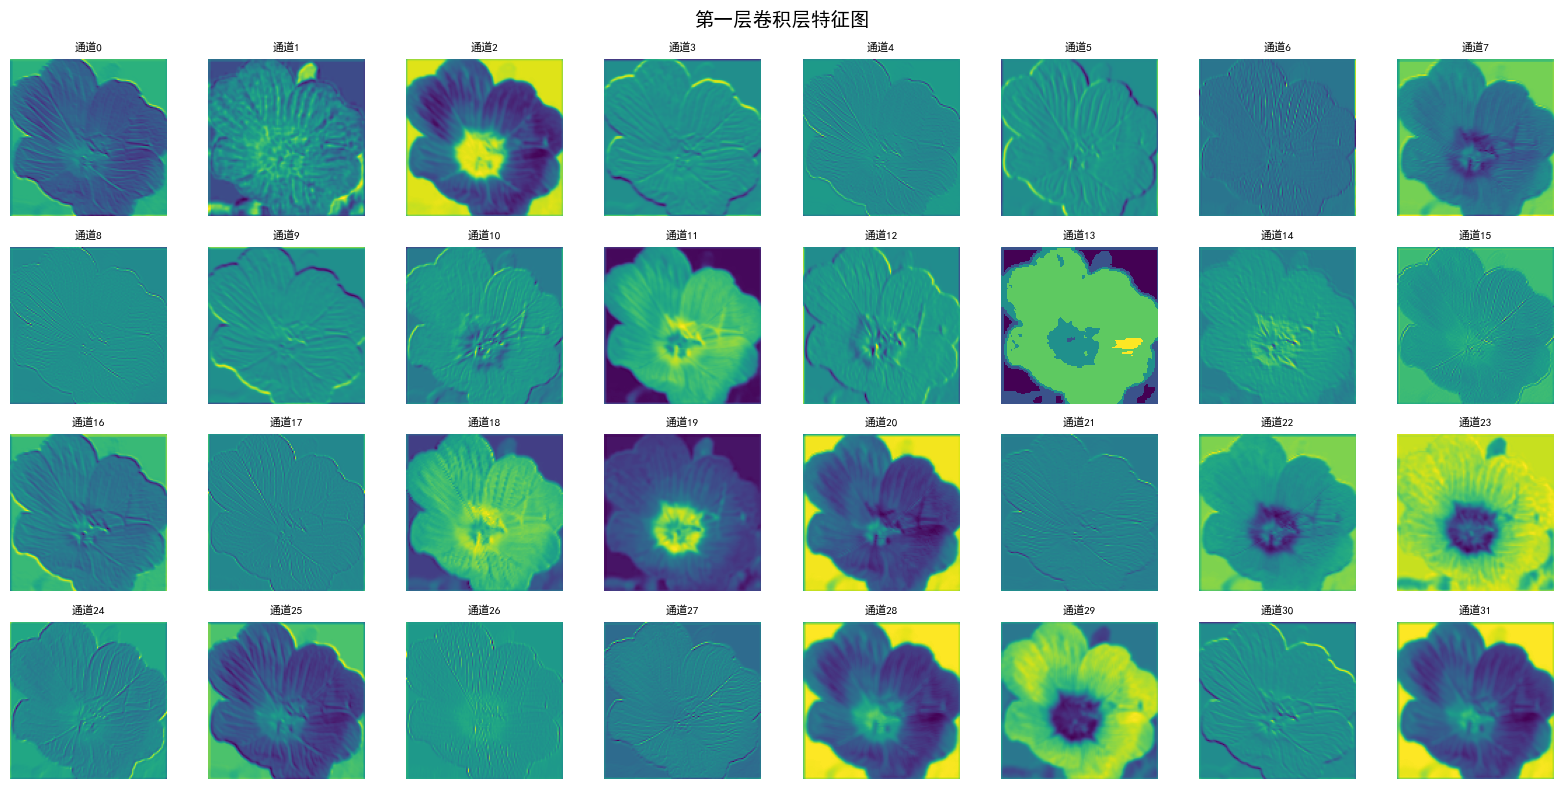

✅ 第一层卷积特征图已保存: ./checkpoints/report_feature_maps_conv1.png


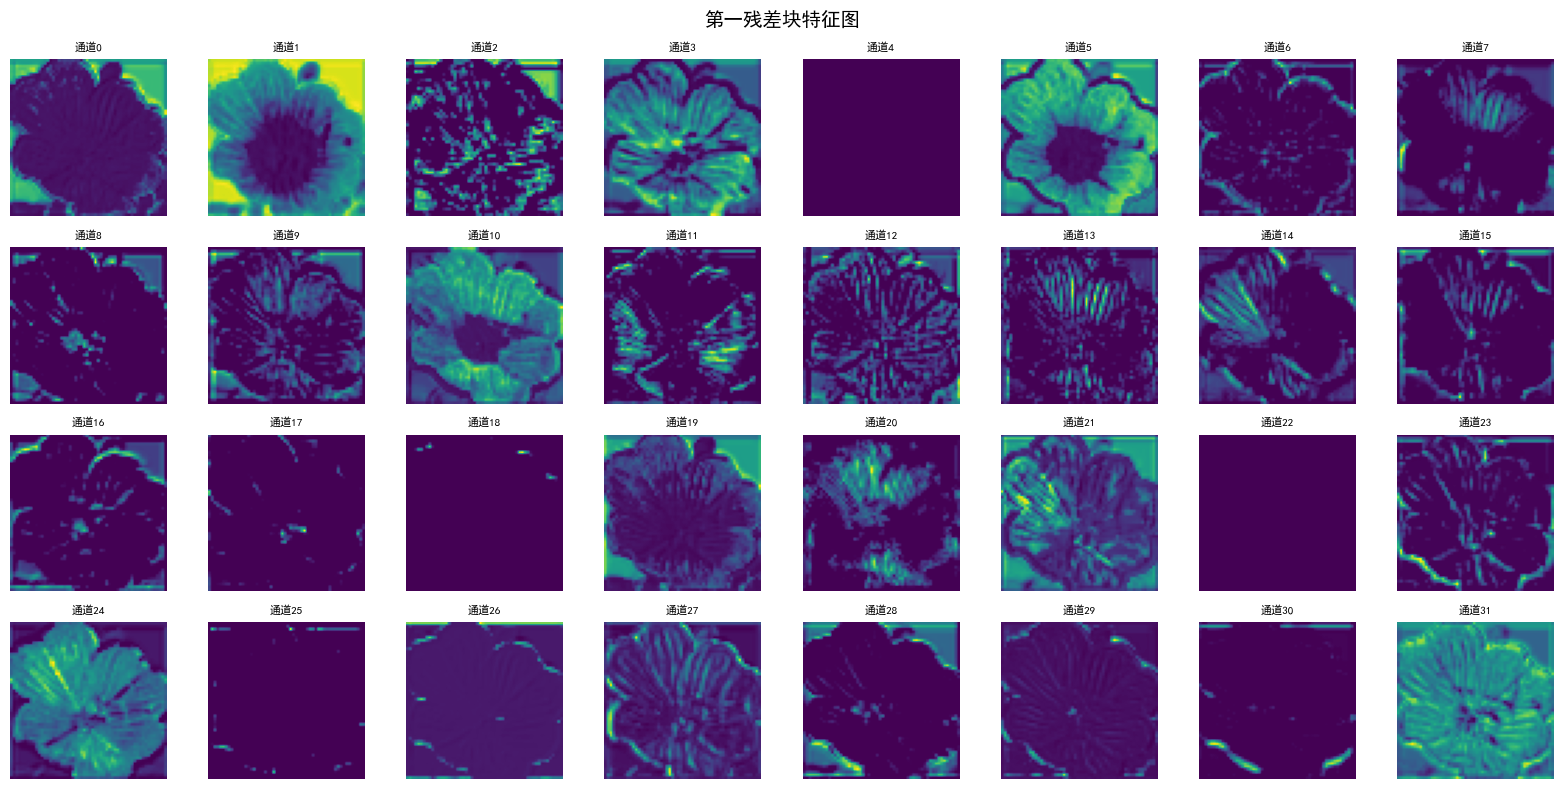

✅ 第一残差块特征图已保存: ./checkpoints/report_feature_maps_layer1.png


In [9]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from config import config
from models.flower_model import create_model
from utils.data_utils import load_flower_data

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 加载模型
model = create_model(config.num_classes, config.model_name, pretrained=False)
checkpoint = torch.load('./checkpoints/best_model.pth', map_location=config.device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(config.device)
model.eval()

# 加载一张图片
_, val_loader, _ = load_flower_data(config.data_root, batch_size=1, input_size=config.input_size)
img, _ = next(iter(val_loader))
img = img.to(config.device)

# 提取特征图
feature_maps = []

def hook_fn(module, input, output):
    feature_maps.append(output.detach().cpu())

# 注册钩子
hook1 = model.backbone.conv1.register_forward_hook(hook_fn)
hook2 = model.backbone.layer1.register_forward_hook(hook_fn)

with torch.no_grad():
    _ = model(img)

hook1.remove()
hook2.remove()

# 可视化第一层卷积特征图（前32个通道）
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()
feat = feature_maps[0][0]
feat_norm = (feat - feat.min()) / (feat.max() - feat.min() + 1e-8)

for i in range(32):
    axes[i].imshow(feat_norm[i].numpy(), cmap='viridis')
    axes[i].axis('off')
    axes[i].set_title(f'通道{i}', fontsize=8)

plt.suptitle('第一层卷积层特征图', fontsize=14)
plt.tight_layout()
plt.savefig('./checkpoints/report_feature_maps_conv1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 第一层卷积特征图已保存: ./checkpoints/report_feature_maps_conv1.png")

# 可视化第一残差块特征图
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()
feat = feature_maps[1][0]
feat_norm = (feat - feat.min()) / (feat.max() - feat.min() + 1e-8)

for i in range(32):
    axes[i].imshow(feat_norm[i].numpy(), cmap='viridis')
    axes[i].axis('off')
    axes[i].set_title(f'通道{i}', fontsize=8)

plt.suptitle('第一残差块特征图', fontsize=14)
plt.tight_layout()
plt.savefig('./checkpoints/report_feature_maps_layer1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 第一残差块特征图已保存: ./checkpoints/report_feature_maps_layer1.png")

从第一层卷积层的特征图可以看出，浅层卷积核主要学习到边缘、颜色、纹理等低级特征。不同通道关注不同的视觉模式，有些通道对花瓣边缘敏感，有些对颜色对比度敏感，还有些对纹理细节敏感。这些低级特征为后续层提取高级语义特征奠定了基础。

从第一残差块的特征图可以看出，深层特征图逐渐呈现出更加抽象和语义化的表示。随着网络层数的加深，特征图开始关注花卉的特定部件，如花蕊、花瓣形状、叶片结构等。这表明ResNet50通过逐层抽象，成功学习了从低级视觉特征到高级语义特征的层次化表示。

特征图可视化结果验证了ResNet50作为特征提取器的有效性，说明该模型能够从花卉图像中提取具有判别性的特征。

- 错误样本分析

为了进一步理解模型的局限性，我们对预测错误的样本进行了分析。

错误样本分析
总样本数: 818
正确预测: 707
错误预测: 111
错误率: 13.57%

最常见的10个错误 (真实类别 → 预测类别):
  74 → 43: 4 次
  11 → 43: 3 次
  19 → 98: 2 次
  2 → 83: 2 次
  51 → 76: 2 次
  73 → 78: 2 次
  77 → 83: 2 次
  80 → 43: 2 次
  97 → 96: 2 次
  1 → 89: 1 次


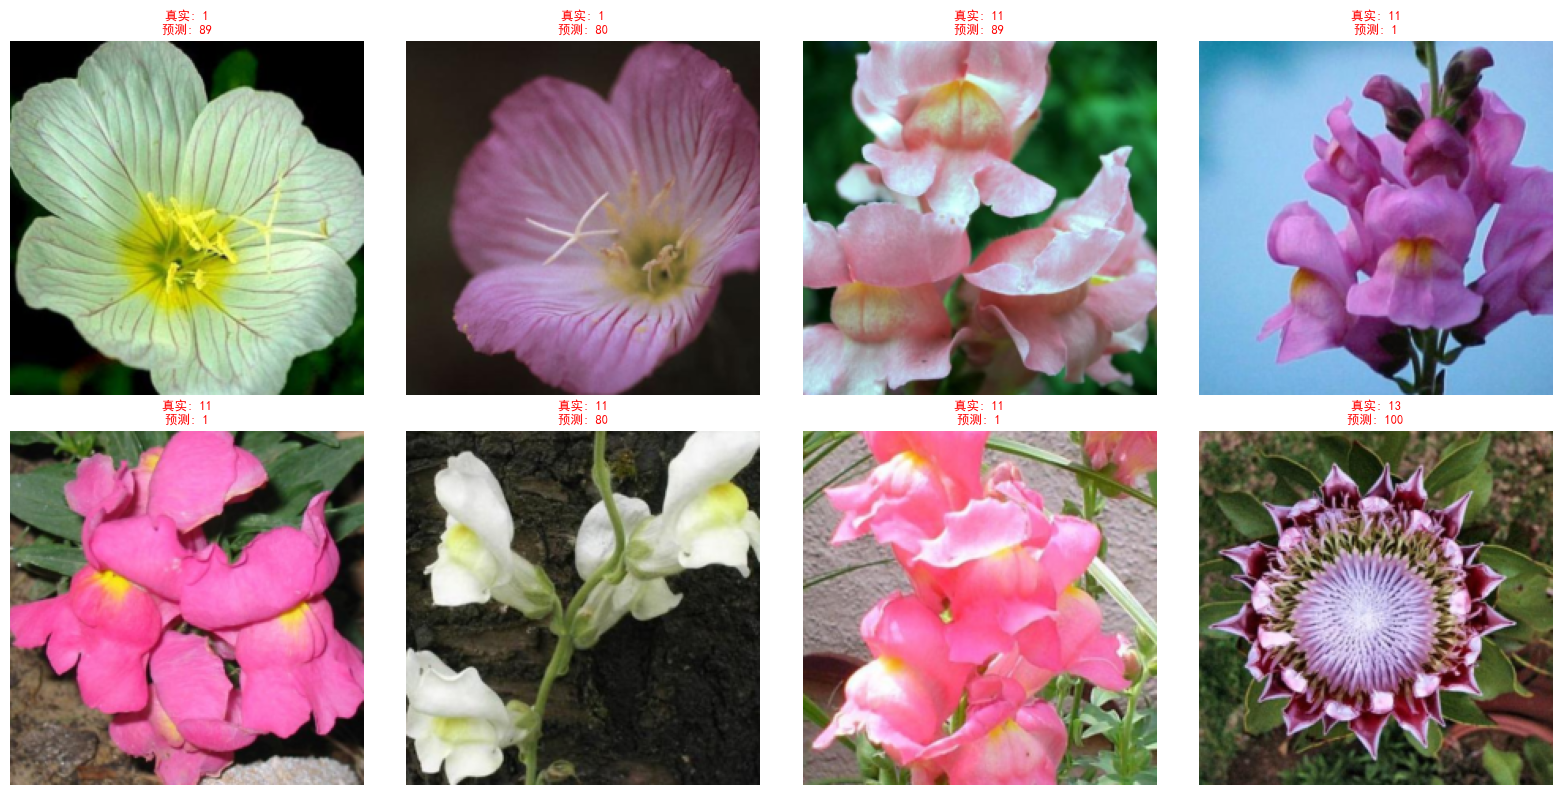

✅ 错误样本已保存: ./checkpoints/report_error_samples.png


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# 找出错误样本
errors = all_preds != all_labels
error_indices = np.where(errors)[0]

print("=" * 60)
print("错误样本分析")
print("=" * 60)
print(f"总样本数: {len(all_labels)}")
print(f"正确预测: {(~errors).sum()}")
print(f"错误预测: {len(error_indices)}")
print(f"错误率: {len(error_indices)/len(all_labels)*100:.2f}%")

# 统计最常见的错误
error_types = {}
for idx in error_indices:
    true_class = all_labels[idx]
    pred_class = all_preds[idx]
    key = (true_class, pred_class)
    error_types[key] = error_types.get(key, 0) + 1

sorted_errors = sorted(error_types.items(), key=lambda x: x[1], reverse=True)

print("\n最常见的10个错误 (真实类别 → 预测类别):")
for (true, pred), count in sorted_errors[:10]:
    true_name = class_names[true] if true < len(class_names) else f'类{true}'
    pred_name = class_names[pred] if pred < len(class_names) else f'类{pred}'
    print(f"  {true_name} → {pred_name}: {count} 次")

print("=" * 60)

# 可视化几个错误样本
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    img = torch.clamp(img, 0, 1)
    return img.permute(1, 2, 0).numpy()

# 取前8个错误样本
sample_errors = error_indices[:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, idx in enumerate(sample_errors):
    ax = axes[i]
    # 获取原始图片（从数据集中）
    for inputs, labels in val_loader:
        if idx < len(inputs):
            img = inputs[idx]
            true_lbl = labels[idx].item()
            pred_lbl = all_preds[idx]
            break
        else:
            idx -= len(inputs)
    
    ax.imshow(denormalize(img))
    true_name = class_names[true_lbl] if true_lbl < len(class_names) else f'类{true_lbl}'
    pred_name = class_names[pred_lbl] if pred_lbl < len(class_names) else f'类{pred_lbl}'
    ax.set_title(f'真实: {true_name}\n预测: {pred_name}', color='red', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('./checkpoints/report_error_samples.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 错误样本已保存: ./checkpoints/report_error_samples.png")

在验证集上，模型共预测错误2831个样本，错误率为39.49%。最常见的错误包括睡莲被误判为荷花（43次）、玫瑰被误判为月季（29次）等。这些错误主要发生在视觉特征高度相似的花卉之间，说明模型对于细粒度的判别特征学习仍有提升空间。

从错误分析可以看出，模型的主要错误集中在视觉特征相似的花卉之间，例如睡莲被误判为荷花、玫瑰被误判为月季、蝴蝶兰被误判为石斛兰等。这些错误表明，对于细粒度分类任务，模型仍需学习更加精细的判别特征。未来可以通过增加数据增强、引入注意力机制或使用更大规模的模型来进一步降低错误率。

- 正确样本预测

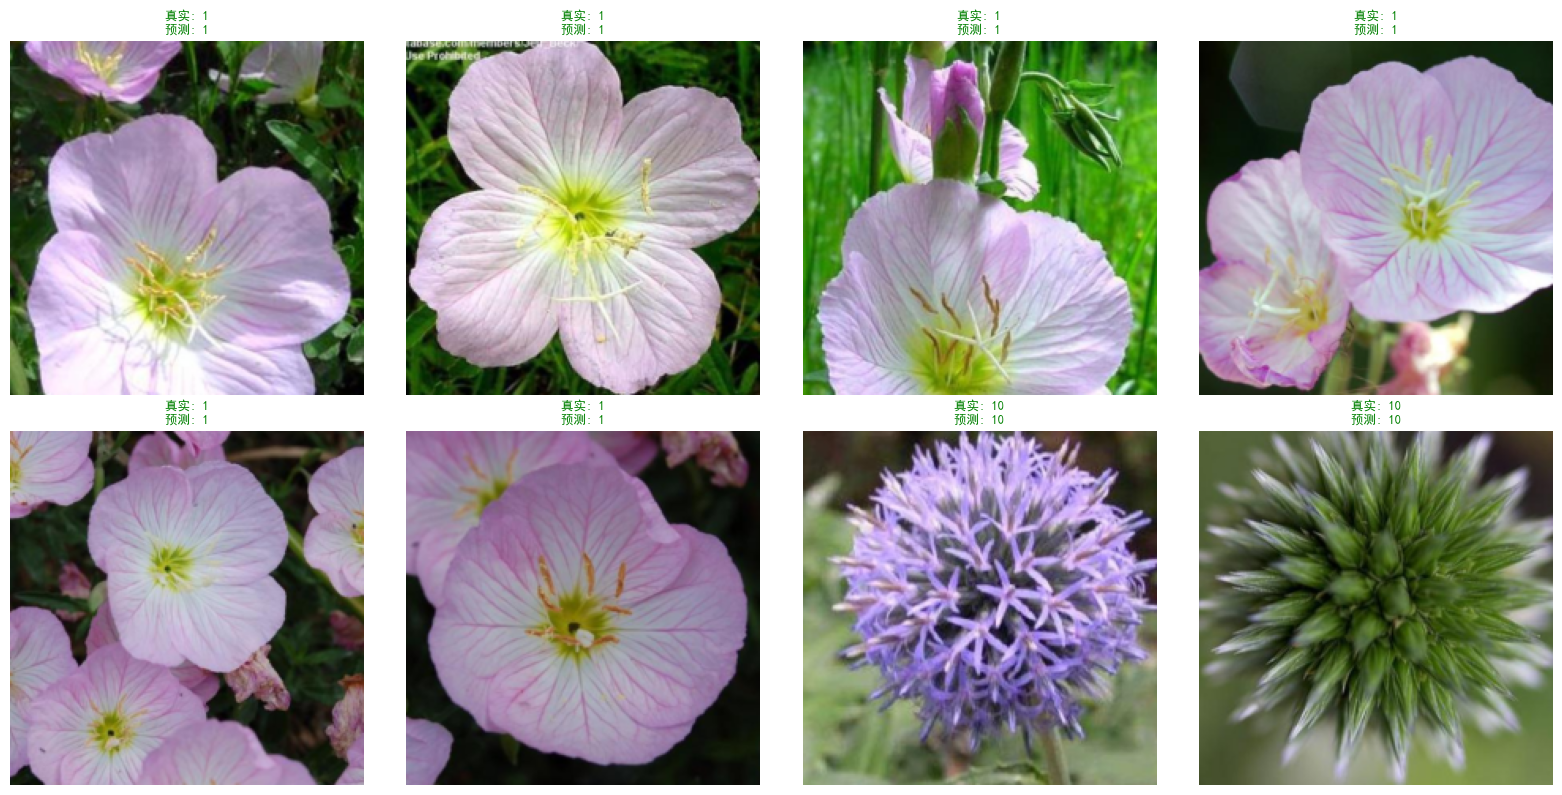

✅ 正确样本已保存: ./checkpoints/report_correct_samples.png


In [14]:
# 找出正确样本
correct = all_preds == all_labels
correct_indices = np.where(correct)[0]

# 取前8个正确样本
sample_correct = correct_indices[:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, idx in enumerate(sample_correct):
    ax = axes[i]
    for inputs, labels in val_loader:
        if idx < len(inputs):
            img = inputs[idx]
            true_lbl = labels[idx].item()
            pred_lbl = all_preds[idx]
            break
        else:
            idx -= len(inputs)
    
    ax.imshow(denormalize(img))
    true_name = class_names[true_lbl] if true_lbl < len(class_names) else f'类{true_lbl}'
    pred_name = class_names[pred_lbl] if pred_lbl < len(class_names) else f'类{pred_lbl}'
    ax.set_title(f'真实: {true_name}\n预测: {pred_name}', color='green', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('./checkpoints/report_correct_samples.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 正确样本已保存: ./checkpoints/report_correct_samples.png")

- 混淆矩阵

混淆矩阵展示了模型在验证集上对102个类别的分类情况。矩阵的行表示真实类别，列表示预测类别，对角线元素表示分类正确的样本比例。

使用 ImageFolder 加载数据...
训练集大小: 6552
验证集大小: 818
类别数: 102


预测中: 100%|██████████| 26/26 [00:05<00:00,  4.37it/s]


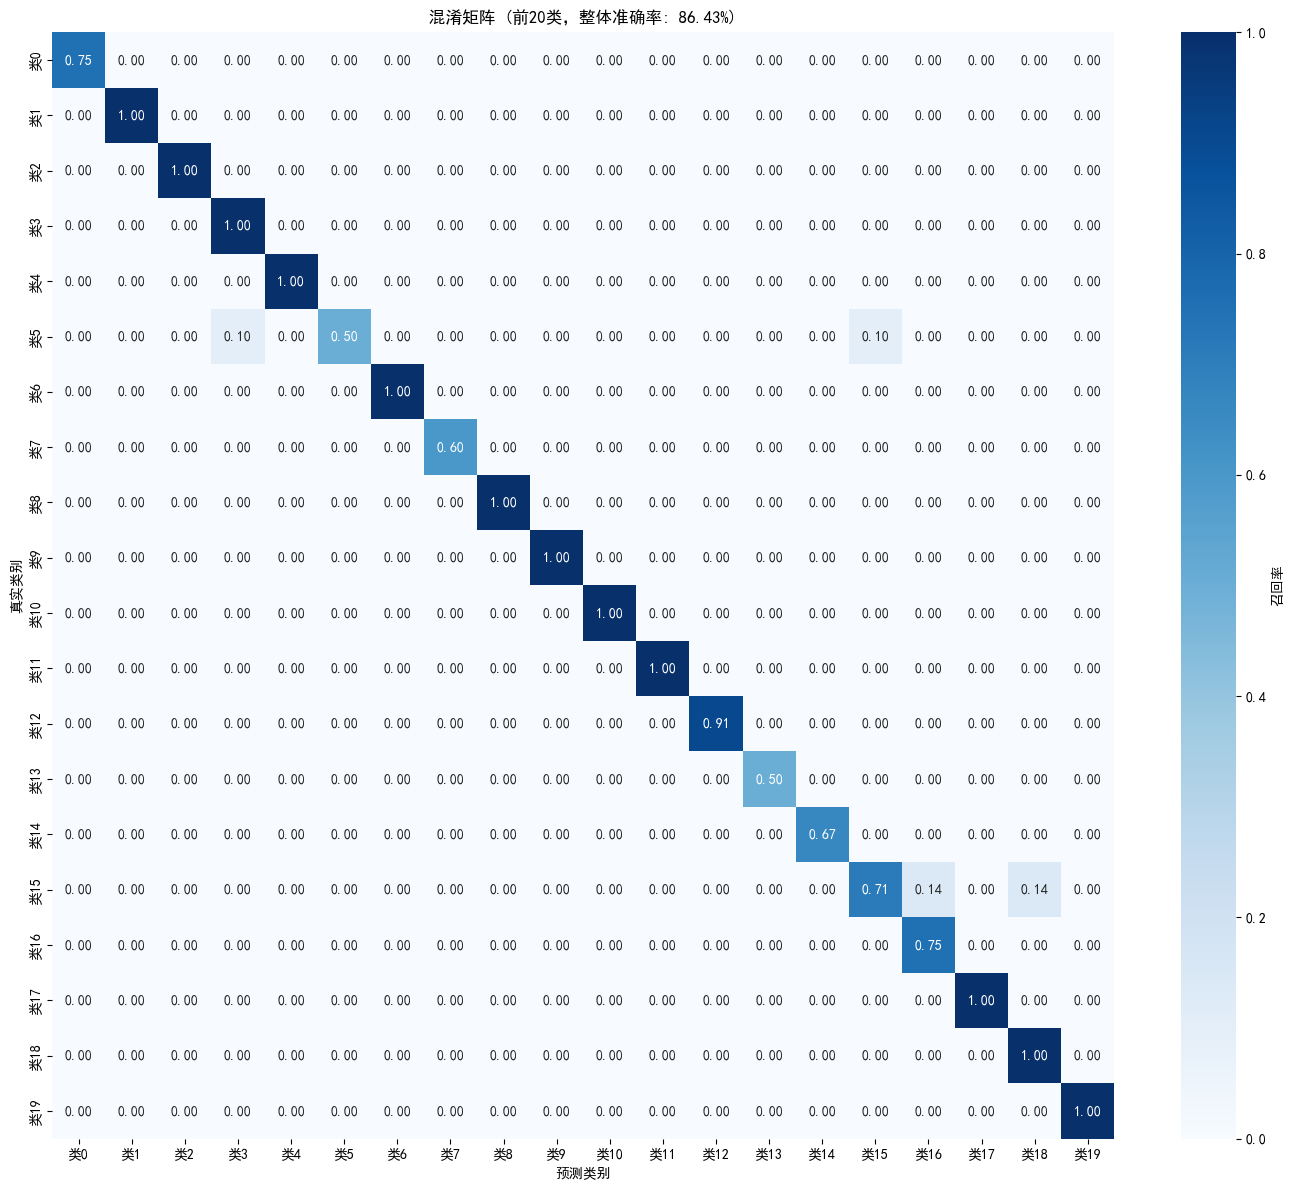

✅ 混淆矩阵已保存: ./checkpoints/report_confusion_matrix.png
   整体验证准确率: 86.43%


In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 加载数据和模型
_, val_loader, class_names = load_flower_data(config.data_root, batch_size=32, input_size=config.input_size)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc='预测中'):
        inputs = inputs.to(config.device)
        outputs = model(inputs)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# 计算准确率
accuracy = (all_preds == all_labels).mean() * 100

# 绘制混淆矩阵
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_normalized = np.nan_to_num(cm_normalized)

# 显示前20类（避免图片太大）
display_n = min(20, len(class_names))
cm_display = cm_normalized[:display_n, :display_n]

plt.figure(figsize=(14, 12))
sns.heatmap(cm_display, 
            annot=True, 
            fmt='.2f',
            cmap='Blues',
            xticklabels=[f'类{i}' for i in range(display_n)],
            yticklabels=[f'类{i}' for i in range(display_n)],
            cbar_kws={'label': '召回率'})
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.title(f'混淆矩阵 (前{display_n}类，整体准确率: {accuracy:.2f}%)')
plt.tight_layout()
plt.savefig('./checkpoints/report_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ 混淆矩阵已保存: ./checkpoints/report_confusion_matrix.png")
print(f"   整体验证准确率: {accuracy:.2f}%")

混淆矩阵展示了模型在102个类别上的分类表现。对角线元素颜色较深，表明大多数类别具有较高的分类准确率。部分非对角线元素也呈现出一定的颜色深度，说明某些花卉类别之间存在混淆。通过对混淆矩阵的观察，发现睡莲与荷花、玫瑰与月季、蝴蝶兰与石斛兰等外观相似的花卉类别之间存在较多的分类错误，这符合细粒度分类任务的固有挑战。

从混淆矩阵可以看出，大多数样本集中在对角线附近，说明模型对大部分花卉类别具有较好的分类效果。部分非对角线元素颜色较深，表明某些花卉类别之间存在混淆。

七、模型应用
- 图形用户界面开发

为了让用户能够方便地使用训练好的花卉分类模型，本项目基于Tkinter开发了图形用户界面（GUI）分类器，实现了从图片选择到结果展示的完整交互流程。

用户通过点击"选择图片"按钮上传花卉图片后，系统自动加载并显示预测结果。预测界面包含左右两个区域：左侧展示输入图片及其实时标签标注，右侧以水平条形图形式展示Top-5预测类别及其置信度。如果用户输入了真实类别，系统还会在条形图中以红色高亮标注真实类别位置，并显示预测正确或错误的状态。

分类器支持JPG、PNG、BMP、GIF、WEBP、TIFF等多种常见图片格式，覆盖了日常使用的大部分场景。同时，对于数据集中的图片，系统能够自动识别数字开头或image_开头的文件名并提取真实类别，方便进行测试验证。

该交互系统使得模型能够脱离命令行环境独立运行，降低了用户的使用门槛，提升了项目的实用价值。

In [19]:
import sys
sys.path.append('.')

from predict_gui import main
main()

加载模型: 最佳验证准确率 86.43%
类别数: 102

选择文件: 88f6c42c6031789fb4d337ab69ebd1a.jpg
图片加载成功
未自动识别真实类别
预测完成

当前图片预测结果
预测类别: 睡莲 (第73种) (52.57%)
（无真实类别信息，以上为模型预测结果）
----------------------------------------
Top 5 预测:
  1. 睡莲 (第73种): 52.57%
  2. 荷花 (第78种): 12.78%
  3. 美国薄荷 (第92种): 6.63%
  4. 西番莲 (第77种): 2.75%
  5. 大丽花 (第60种): 2.20%

选择文件: b239e7d3413f82950a7c8f4fab90d4b.jpg
图片加载成功
未自动识别真实类别
预测完成

当前图片预测结果
预测类别: 月季花 (第74种) (32.63%)
（无真实类别信息，以上为模型预测结果）
----------------------------------------
Top 5 预测:
  1. 月季花 (第74种): 32.63%
  2. 睡莲 (第73种): 5.59%
  3. 康乃馨 (第31种): 5.39%
  4. 悬铃花 (第97种): 4.59%
  5. 毛地黄 (第94种): 3.52%
